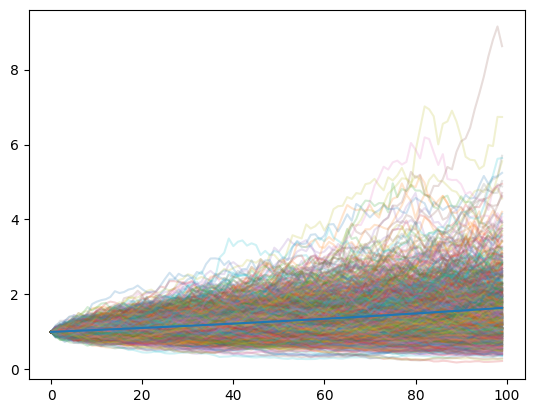

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

mu = 0.5
sigma = 0.5
rr = mu - sigma**2/2
def simulate(grid, n_samples):
  """
  Vectorised simulation of the underlying price under log-normal returns hypothesis
  """
  n_grid = len(grid)
  incr = stats.norm.rvs(size=(n_samples, n_grid-1))
  dt = np.diff(grid)
  dW = incr * np.sqrt(dt[None, :])
  W = np.cumsum(dW, axis=-1)
  W = np.hstack([np.zeros((n_samples, 1)), W])
  return np.exp(rr * grid + sigma * W), W, grid


def halve_grid(grid):
  """
  Given some grid of size n, x0, x1, ... x_{n-1},
  returns the grid of size n + n - 1, x0, (x0+x1)/2, x1, ..., x_{n-2}, (x_{n-2}+x_{n-1})/2, x_{n-1}
  """
  n = len(grid)
  new_grid = np.zeros(2*(n-1)+1)
  new_grid[0] = grid[0]
  for i in range(1, n):
    new_grid[2 * i] = grid[i]
    new_grid[2 * i -1] = (grid[i-1]+ grid[i])/2
  return new_grid

def inner_simulate(brownian_paths, paths, grid):
  """
  Refining the time grid using Brownian bridge interpolation
  """
  new_grid = halve_grid(grid)
  n = len(grid)
  n_samples = paths.shape[0]
  new_brownian_paths = np.zeros((n_samples, len(new_grid)))
  new_paths = np.zeros((n_samples, len(new_grid)))
  new_brownian_paths[:, 0] = brownian_paths[:, 0]
  new_paths[:, 0] = paths[:, 0]
  incr = stats.norm.rvs(size=(n_samples, n - 1))
  for i in range(1, n):
    new_brownian_paths[:, 2 * i] = brownian_paths[:, i]
    t = new_grid[2*i-1]
    a = grid[i-1]
    b = grid[i]
    new_brownian_paths[:, 2 * i -1] = (t - a)/(b-a) * brownian_paths[:, i] + (b-t)/(b-a) * brownian_paths[:, i-1] + np.sqrt((b-t)*(t-a)/(b-a))*incr[:,i-1]
    new_paths[:, 2*i] = paths[:, i]
    new_paths[:, 2*i-1] = paths[:, i-1] * np.exp( rr *(t-a)) * np.exp(sigma * (new_brownian_paths[:, 2*i-1]-new_brownian_paths[:, 2*i-2]))
  return new_paths, new_brownian_paths, new_grid

def inner_simulate_no_for_loop(brownian_paths, paths, grid):
  """
  Same as previously but no for loop
  """
  new_grid = halve_grid(grid)
  n = len(grid)
  n_samples = paths.shape[0]
  new_brownian_paths = np.zeros((n_samples, len(new_grid)))
  new_paths = np.zeros((n_samples, len(new_grid)))
  new_brownian_paths[:, 0] = brownian_paths[:, 0]
  new_paths[:, 0] = paths[:, 0]
  incr = stats.norm.rvs(size=(n_samples, n - 1))
  new_brownian_paths[:, ::2] = brownian_paths
  t_middle = new_grid[1::2]
  a = grid[:-1]
  b = grid[1:]
  bminusa = np.diff(grid)
  new_brownian_paths[:, 1::2] = (t_middle-a)/bminusa * brownian_paths[:, 1:] + (b-t_middle)/bminusa * brownian_paths[:, :-1] + np.sqrt((b-t_middle)*(t_middle-a)/(b-a)) * incr
  new_paths[:, ::2] = paths
  new_paths[:, 1::2] = paths[:, :-1] * np.exp(rr * (t_middle -a ))[None, :] * np.exp(sigma * (new_brownian_paths[:, 1::2]-brownian_paths[:,:-1]))
  return new_paths, new_brownian_paths, new_grid
n_samples = 1000
grid = np.arange(0, 1, 1/100)
paths, _,_  = simulate(grid, n_samples)
plt.plot(paths.T, alpha=0.2);
plt.plot(np.exp(mu * grid))

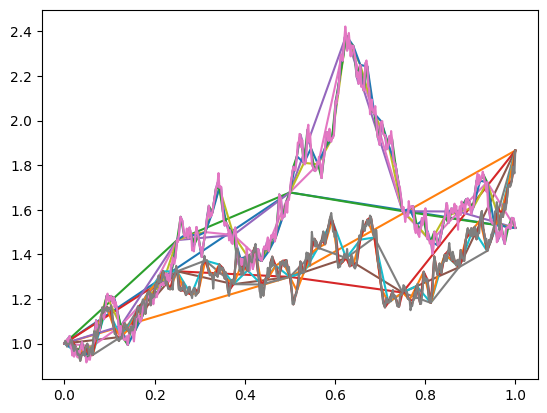

In [ ]:
grid0 = np.array([0., 1.])
n_samples = 2
paths, brownian_paths, grid = simulate(grid0, n_samples)
for k in range(1, 10):
  paths, brownian_paths, grid = inner_simulate(brownian_paths, paths, grid)
  plt.plot(grid, paths.T)

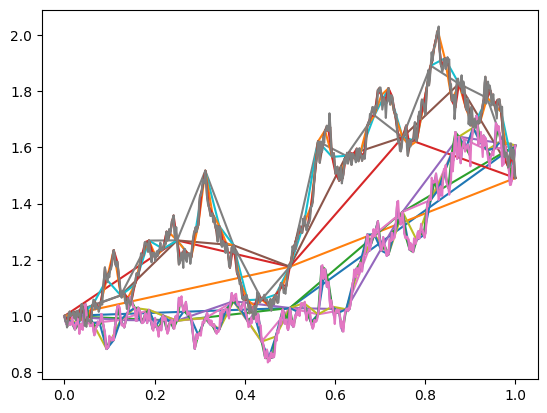

In [ ]:
grid0 = np.array([0., 1.])
n_samples = 2
paths, brownian_paths, grid = simulate(grid0, n_samples)
for k in range(1, 10):
  paths, brownian_paths, grid = inner_simulate_no_for_loop(brownian_paths, paths, grid)
  plt.plot(grid, paths.T)

(8193, 10)
(10,)
0.42366113663380583 0.1563528893104893
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 0
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 1
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 2
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 3
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 4
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 5
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 6
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 7
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 8
(np.float64(0.4540300843850152), np.float64(0.16710069300395458)), 9


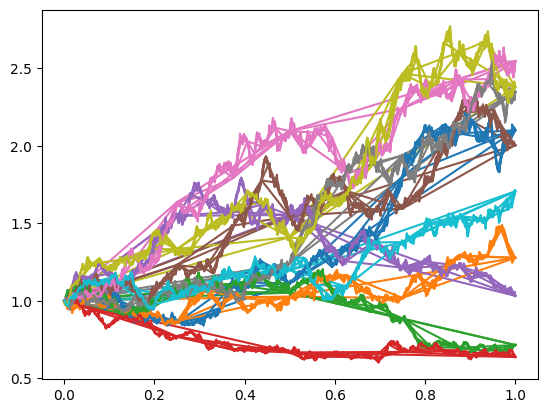

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Home implementation

def halve_grid(grid):
    """
    Halve the grid by inserting midpoints between each consecutive points
    """
    n = len(grid)
    new_grid = np.zeros(2*(n-1) + 1)
    new_grid[0] = grid[0]
    for i in range(1, n):
        new_grid[2*i] = grid[i]
        new_grid[2*i-1] = (grid[i] + grid[i-1]) / 2
    return new_grid

def rec_halve_grid(grid, k):
    if k==0:
        return grid
    else:
        new_grid = halve_grid(grid)
        return rec_halve_grid(new_grid, k-1)

def simulate(N_samples, grid):
    n = len(grid)
    s = mu - sigma**2/2
    incrs = stats.norm.rvs(size=(N_samples, n-1)) * np.sqrt(np.diff(grid)[None, :])
    brownian_paths = np.hstack([np.zeros((N_samples, 1)), np.cumsum(incrs, axis=-1)])
    paths = np.exp(brownian_paths * sigma) * np.exp(s * grid)[None, :]
    return paths, brownian_paths

def inner_simulate(brownian_paths, paths, grid):
    new_grid = halve_grid(grid)
    n = len(grid)
    s = mu - sigma**2/2
    thinner_brownian_paths = np.zeros((brownian_paths.shape[0], len(new_grid)))
    thinner_paths = np.zeros((paths.shape[0], len(new_grid)))
    new_incrs = stats.norm.rvs(size=(N_samples, 2*(n-1)+1-n)) * np.sqrt(np.diff(new_grid)[None, 1::2]/4)
    thinner_brownian_paths[:, 0] = brownian_paths[:, 0]
    thinner_paths[:, 0] = paths[:, 0]
    for i in range(1, n):
        thinner_brownian_paths[:, 2*i] = brownian_paths[:, i]
        thinner_brownian_paths[:, 2*i-1] = (grid[i] - new_grid[2*i-1])/(grid[i]-grid[i-1]) * brownian_paths[:, i-1] + \
                (new_grid[2*i-1] - grid[i-1])/(grid[i]-grid[i-1]) * brownian_paths[:, i] + new_incrs[:,i-1]
        thinner_paths[:, 2*i] = paths[:, i]
        thinner_paths[:, 2*i-1] = paths[:, i-1] * np.exp(s * (new_grid[2*i-1]-grid[i-1])) * np.exp((thinner_brownian_paths[:, 2*i-1]-thinner_brownian_paths[:, 2*i-2])*sigma)

    return thinner_paths, thinner_brownian_paths, new_grid

def payoff(S):
    return np.exp(-r * T) * np.maximum(0, K-S)



if __name__ == "__main__":
    T = 1
    r = 0.02
    mu = 0.5
    sigma = 0.5
    K = 2
    N_samples = 10
    grid0 = np.array([0, 1])
    grid = rec_halve_grid(grid0, 13)
    paths, brownian_paths = simulate(N_samples, grid)
    paths = paths.T
    #plt.plot(paths)
    print(paths.shape)
    gains = payoff(paths[-1])
    print(gains.shape)
    print(np.mean(gains), np.std(gains)/np.sqrt(N_samples))
    #plt.show()

    grid = grid0
    paths, brownian_paths = simulate(N_samples, grid)
    for k in range(10):
        paths, brownian_paths, grid = inner_simulate(brownian_paths, paths, grid)
        plt.plot(grid, paths.T)
        gains = payoff(paths[:,-1])
        print(f'{np.mean(gains), np.std(gains) / np.sqrt(N_samples)}, {k}')

    plt.show()